In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


from core import run_coverage
from config import RESULTS_DIR

In [18]:
# execution
n_sim = 10000
Ts = [100, 500, 3000]
alpha = 0.05
target_coverage = 1.0 - alpha
for T in Ts:
    test_args = [
            "--T", str(T),
            "--n_sim", str(n_sim),
            "--alpha", str(alpha),
            "--theta", "0.5",
            "--dgps", "iid_normal", "iid_t5", "ar1_phi06_normal", "ar1_phi-06_normal",
            "--models", "iid_normal", "iid_student_t", "iid_nonnormal", "ar1_normal",
            #"--th_moments",
            "--seed", "42",
            "--out", str(RESULTS_DIR / f"coverage_an_T{T}_n{n_sim}.csv")
        ]
    run_coverage.main(test_args)



before:  IIDProcess(Normal(μ=0.0, σ=1.0))
after:  IIDProcess(Normal(μ=0.15, σ=0.3))
before:  IIDProcess(StudentT(μ=0.0, df=5, scale=0.7746))
after:  IIDProcess(StudentT(μ=0.15, df=5, scale=0.2324))
before:  ARProcess(phi=[0.6], innov=Normal(μ=0.0, σ=1.0), drift=0.0)
after:  ARProcess(phi=[0.6], innov=Normal(μ=0.0, σ=0.24), drift=0.15)
before:  ARProcess(phi=[-0.6], innov=Normal(μ=0.0, σ=1.0), drift=0.0)
after:  ARProcess(phi=[-0.6], innov=Normal(μ=0.0, σ=0.24), drift=0.15)
  [ 1/16]  DGP=iid_normal                    Model=IID Normal             ... cov=0.949 [OK]
  [ 2/16]  DGP=iid_normal                    Model=IID Student-t          ... cov=0.943 [OK]
  [ 3/16]  DGP=iid_normal                    Model=IID Non-Normal         ... cov=0.947 [OK]
  [ 4/16]  DGP=iid_normal                    Model=AR(1) Normal           ... cov=0.947 [OK]
  [ 5/16]  DGP=iid_t5                        Model=IID Normal             ... cov=0.924 [!!]
  [ 6/16]  DGP=iid_t5                        Model=IID St

In [19]:

alpha = 0.05
target_coverage = 1.0 - alpha 

# 1. Read and combine the data
all_data = []
for T in Ts:
    file_path = RESULTS_DIR / f"coverage_an_T{T}_n{n_sim}.csv"
    
    # Read the CSV
    df_temp = pd.read_csv(file_path)
    
    # Add the trajectory length 'T' as a column for our x-axis
    df_temp["T"] = T 
    
    all_data.append(df_temp)

# Combine into a single DataFrame
df_results = pd.concat(all_data, ignore_index=True)

# Display the table focusing on the key metrics
columns_to_show = ["T", "dgp_name", "avar_model", "nominal_coverage", "coverage", "bias", "rmse"]
print("=== Combined Results Table ===")
print(df_results[columns_to_show].to_string(index=False))

df_results["dgp_model_pair"] = df_results["dgp_name"] + " + " + df_results["avar_model"]

=== Combined Results Table ===
   T          dgp_name     avar_model  nominal_coverage  coverage      bias     rmse
 100        iid_normal     IID Normal              0.95    0.9494  0.001226 0.107136
 100        iid_normal  IID Student-t              0.95    0.9433  0.003848 0.109003
 100        iid_normal IID Non-Normal              0.95    0.9466  0.001263 0.107098
 100        iid_normal   AR(1) Normal              0.95    0.9467  0.003730 0.107116
 100            iid_t5     IID Normal              0.95    0.9245  0.010788 0.118370
 100            iid_t5  IID Student-t              0.95    0.9434  0.011112 0.116694
 100            iid_t5 IID Non-Normal              0.95    0.9331  0.011199 0.118690
 100            iid_t5   AR(1) Normal              0.95    0.9212  0.010925 0.117755
 100  ar1_phi06_normal     IID Normal              0.95    0.6873  0.016436 0.210699
 100  ar1_phi06_normal  IID Student-t              0.95    0.6822  0.016470 0.211479
 100  ar1_phi06_normal IID Non-Nor

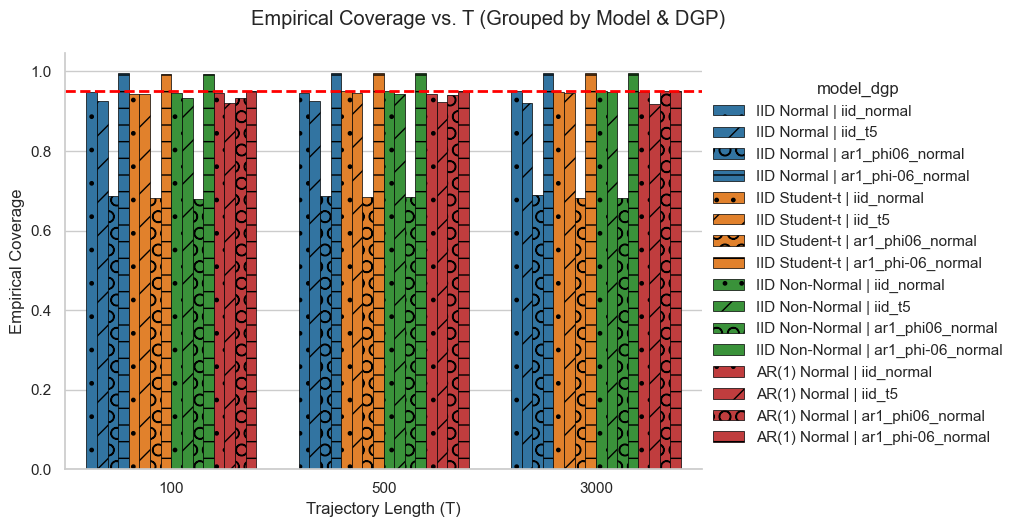

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_coverage_results_by_pair(df, target_val=0.95):
    """
    Plots coverage vs. T.
    Same avar_model gets the same base color.
    Different dgp_name gets a different hatch pattern.
    """
    sns.set_theme(style="whitegrid")
    df = df.copy()
    
    # 1. Create a combined category so seaborn plots them side-by-side
    df["model_dgp"] = df["avar_model"].astype(str) + " | " + df["dgp_name"].astype(str)
    
    # Extract unique values to assign consistent colors and hatches
    models = df["avar_model"].unique()
    dgps = df["dgp_name"].unique()
    t_levels = df["T"].unique()
    
    # 2. Map colors (Model) and hatches (DGP)
    base_colors = sns.color_palette("tab10", len(models))
    color_map = dict(zip(models, base_colors))
    
    hatch_patterns = ['.', '/', 'O', '-', '*']
    hatch_map = dict(zip(dgps, hatch_patterns[:len(dgps)]))
    
    # 3. Build a custom palette mapping the combined name to the Model's color
    hue_order = []
    custom_palette = {}
    for m in models:
        for d in dgps:
            combo_name = f"{m} | {d}"
            hue_order.append(combo_name)
            custom_palette[combo_name] = color_map[m]
            
    # 4. Plot the bars
    g = sns.catplot(
        data=df,
        x="T",
        y="coverage",
        hue="model_dgp", 
        hue_order=hue_order,
        palette=custom_palette,
        kind="bar",
        height=5,
        aspect=1.5,
        errorbar=None
    )
    
    # 5. Loop through the generated bars and apply hatches
    for ax in g.axes.flat:
        ax.axhline(target_val, color='red', linestyle='--', linewidth=2, label=f'Target ({target_val})')
        
        # Seaborn draws bars in the exact order of 'hue_order', across all 'T' values
        for i, bar in enumerate(ax.patches):
            hue_idx = i // len(t_levels) # Figure out which hue group this bar belongs to
            if hue_idx < len(hue_order):
                combo_name = hue_order[hue_idx]
                _, dgp_name = combo_name.split(" | ")
                
                # Apply hatch and add a thin black edge so the hatch is visible
                bar.set_hatch(hatch_map[dgp_name])
                bar.set_edgecolor("black")
                bar.set_linewidth(0.5)
                
    # 6. Apply hatches to the legend so it matches the plot
    if g.legend:
        # Depending on the Matplotlib version, handles are accessed differently.
        handles = getattr(g.legend, "legend_handles", g.legend.get_patches())
        for handle, text in zip(handles, g.legend.texts):
            label = text.get_text()
            if " | " in label:
                _, dgp_name = label.split(" | ")
                handle.set_hatch(hatch_map[dgp_name])
                handle.set_edgecolor("black")
                handle.set_linewidth(0.5)

    # Formatting
    g.fig.suptitle("Empirical Coverage vs. T (Grouped by Model & DGP)", y=1.05)
    g.set_axis_labels("Trajectory Length (T)", "Empirical Coverage")
    
    plt.show()
plot_coverage_results_by_pair(df_results, target_val=target_coverage)

In [ ]:
#plt.ylim(target_val - 0.05, target_val + 0.05)
plot_coverage_results_by_pair(df_results, target_val=target_coverage, group_by="model")

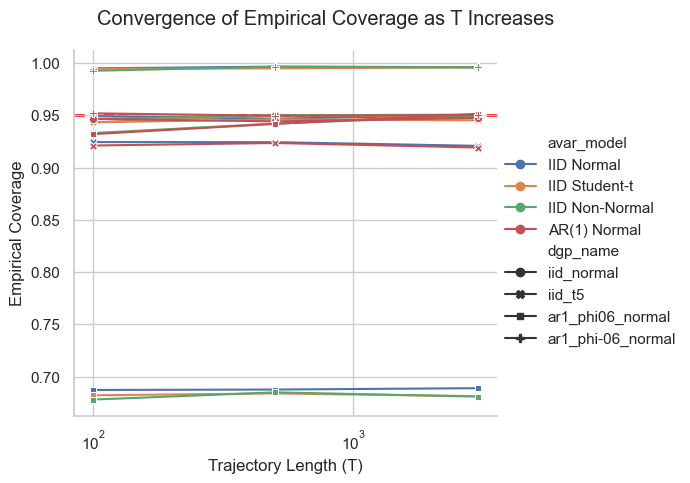

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_coverage_convergence(df, target_val=0.95):
    """
    Plots a line chart showing the convergence of empirical coverage 
    as trajectory length (T) increases.
    - Color = avar_model (aggregated across DGPs)
    - Line style = dgp_name
    """
    sns.set_theme(style="whitegrid")

    g = sns.relplot(
        data=df,
        x="T",
        y="coverage",
        hue="avar_model",
        style="dgp_name",       # Still drives marker variation
        dashes=False,           # All lines solid
        markers=True,           # Vary marker shape per dgp_name
        kind="line",
        marker="o",
        height=4.5,
        aspect=1.2,
        errorbar=None
    )

    for ax in g.axes.flat:
        ax.axhline(
            target_val,
            color='red',
            linestyle='--',
            linewidth=2,
            zorder=0
        )
        ax.set_xscale("log")

    g.fig.suptitle("Convergence of Empirical Coverage as T Increases", y=1.05)
    g.set_axis_labels("Trajectory Length (T)", "Empirical Coverage")

    plt.show()

plot_coverage_convergence(df_results, target_val=target_coverage)